### 1.Import thư viện PaddleOCR

In [ ]:
# Cài PaddlePaddle-GPU (khớp CUDA 13.0 của Colab)
# !python -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!python -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/
# Cài PaddleOCR
!pip install pymupdf
!python -m pip install -U paddleocr

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu130/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 981.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# Cài PaddleOCR & PaddleX với các extras [ocr,ie,doc-parser] siêu nhanh
!uv pip install "paddlex[ocr,ie]" "paddleocr[doc-parser]" pymupdf
!uv pip install safetensors

Using Python 3.12.13 environment at: C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv
Resolved 116 packages in 1.55s
 Downloaded sentencepiece
 Downloaded shapely
 Downloaded pycryptodome
 Downloaded hf-xet
 Downloaded pypdfium2
 Downloaded langchain-community
 Downloaded paddlex
 Downloaded openai
 Downloaded scikit-learn
 Downloaded pandas
 Downloaded modelscope
 Downloaded numpy
 Downloaded pymupdf
 Downloaded opencv-contrib-python
Prepared 55 packages in 42.04s
error: failed to remove directory `C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv\Lib\site-packages\numpy.libs`: Access is denied. (os error 5)
Using Python 3.12.13 environment at: C:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv
Checked 1 package in 15ms


In [5]:
# Kiểm tra cài thành công chưa?
import paddle
print("PaddlePaddle version:", paddle.__version__)
print("GPU available:", paddle.device.is_compiled_with_cuda())

import paddlex
print("paddlex version:", paddlex.__version__)

import paddleocr
print("PaddleOCR version:", paddleocr.__version__)

PaddlePaddle version: 3.3.1
GPU available: True
paddlex version: 3.7.2
PaddleOCR version: 3.7.0


### Data

In [16]:
# Display image and DPI
import matplotlib.pyplot as plt
from PIL import Image

def show_image(path_or_img, title=None):
    # Mở ảnh nếu đầu vào là đường dẫn
    img = Image.open(path_or_img) if isinstance(path_or_img, str) else path_or_img
    
    # 1. Lấy kích thước pixel gốc của ảnh
    width, height = img.size
    
    # 2. Lấy thông tin DPI gốc từ metadata của ảnh (mặc định là 100 nếu ảnh không lưu DPI)
    dpi_info = img.info.get('dpi', (100, 100))
    dpi_x = dpi_info[0] if isinstance(dpi_info, tuple) else dpi_info
    dpi_y = dpi_info[1] if isinstance(dpi_info, tuple) else dpi_info
    
    
    # 3. Tính toán kích thước figsize (inch) tương ứng
    figsize = (width / dpi_x, height / dpi_y)
    
    # 4. Hiển thị ảnh với figsize và dpi vừa lấy được
    plt.figure(figsize=figsize, dpi=dpi_x)
    plt.imshow(img)
    plt.axis('off')
    
    if title:
        info_str = f"{width}x{height}px | DPI: {int(dpi_x)}"
        display_title = f"{title} ({info_str})" if title else info_str
        plt.title(display_title)
        
    plt.show()

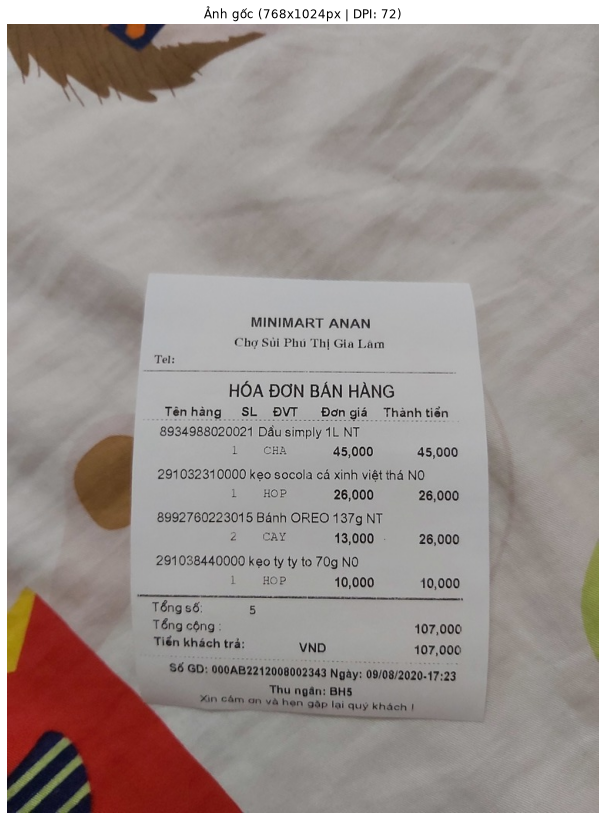

In [17]:
image_patch = r"..\..\data\raw\mc_ocr\mcocr_public\mcocr_train_data\train_images\mcocr_public_145013adyee.jpg"

show_image(image_patch, title="Ảnh gốc")

### PaddleOCR-VL

In [20]:
from paddleocr import PaddleOCRVL

pipeline_vl = PaddleOCRVL(
    # --- Phiên bản model ---
    pipeline_version="v1.6",              # v1 / v1.5 / v1.6 — bản mới nhất, độ chính xác cao nhất (OmniDocBench 96.3%)

    # --- Preprocessing (ảnh chụp tay như hoá đơn nên bật) ---
    use_doc_orientation_classify=False,    # tự xoay lại nếu ảnh chụp ngược/lệch
    use_doc_unwarping=False,               # làm phẳng nếu giấy bị cong/nhăn

    # --- Các module nhận diện thành phần đặc biệt ---
    use_layout_detection=True,            # bật 2-stage: detect vùng → VLM đọc từng vùng (chính xác hơn đọc thẳng cả ảnh)
    use_chart_recognition=False,          # bật nếu ảnh có biểu đồ cần đọc số liệu
    use_seal_recognition=False,           # bật nếu ảnh có con dấu/mộc
    use_ocr_for_image_block=False,        # bật nếu muốn OCR chữ nằm trong vùng bị phân loại là "image"

    # --- Backend chạy VLM ---
    vl_rec_backend="native",              # giữ mặc định "paddle" — an toàn nhất cho GPU T4 Colab, tránh OOM/timeout

    # --- Thiết bị ---
    device="gpu:0",
)

Creating model: ('PP-DocLayoutV3', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Using official model (PP-DocLayoutV3), the model files will be automatically downloaded and saved in `C:\Users\Admin\.paddlex\official_models\PP-DocLayoutV3`.
[2026-07-30 16:49:55,162] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
[2026-07-30 16:49:55,443] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-DocLayoutV3/revision/main "HTTP/1.1 200 OK"
[2026-07-30 16:49:55,731] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-DocLayoutV3/tree/7b48a7566925fa464281f930c58eee04fe2c862a?recursive=true&expand=false "HTTP/1.1 200 OK"
Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s][2026-07-30 16:49:56,068] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-DocLayoutV3/resolve/7b48a7566925fa464281f930c58eee04fe2c862a/inference.json "HTTP/1.1 307 Temporary Redirect"
[2026-07-30 16:49:56,099] [    INFO

In [22]:
# Chạy predict trên hoá đơn
output_vl = pipeline_vl.predict(
    image_patch,
    layout_threshold=0.5,       # ngưỡng tin cậy giữ lại vùng layout — giảm nếu bị sót vùng
    layout_nms=True,            # loại box layout trùng lặp/chồng nhau
)

for res in output_vl:
    res.print()
    res.save_to_json(save_path="output_vl")
    res.save_to_markdown(save_path="output_vl")

c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv\Lib\site-packages\paddle\tensor\creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(
{'res': {'input_path': '..\\..\\data\\raw\\mc_ocr\\mcocr_public\\mcocr_train_data\\train_images\\mcocr_public_145013adyee.jpg', 'page_index': None, 'page_count': None, 'width': 768, 'height': 1024, 'model_settings': {'use_doc_preprocessor': False, 'use_layout_detection': True, 'use_chart_recognition': False, 'use_seal_recognition': False, 'use_ocr_for_image_block': False, 'format_block_content': False, 'merge_layout_blocks': True, 'markdown_ignore_labels': ['number', 'footnote', 'header', 'header_image', 'footer', 'footer_image', 'aside_text'], 'return_layout_polygon_points': True}, 'layout_det_res': {'input_path': None, 'page_index': None, 'boxes': [{'cls_id': 6, 'label': 'doc_title', 'score': 0.704131007194519, 'coordinate': [292

In [23]:
# Xem ảnh layout
import glob
layout_img_vl = glob.glob("output_vl/**/*.png", recursive=True) + glob.glob("output_vl/**/*.jpg", recursive=True)

if layout_img_vl:
    show_image(layout_img_vl[0], figsize=(5, 8), title="PaddleOCR-VL — Layout + VLM Recognition")
else:
    print("Không có ảnh visualize, xem trực tiếp JSON/Markdown ở Cell 35-36")

Không có ảnh visualize, xem trực tiếp JSON/Markdown ở Cell 35-36


In [24]:
# Xem kết quả
import json
import pandas as pd

json_files_vl = glob.glob("output_vl/**/*.json", recursive=True)
with open(json_files_vl[0], "r", encoding="utf-8") as f:
    data_vl = json.load(f)

rows = []
for block in data_vl.get("parsing_res_list", []):
    rows.append({
        "label": block.get("block_label"),
        "content": block.get("block_content"),
        "bbox": block.get("block_bbox"),
    })

df_vl = pd.DataFrame(rows)
df_vl

,label,content,bbox
0,doc_title,MINIMART ANAN\nChợ Sửi Phú Thị Gia Lâm,"[292, 377, 493, 426]"
1,table,"<table><tr><td colspan=""4"">HẠO ĐƠN BẢN HÀNG</t...","[186, 473, 594, 825]"
2,text,Số GD: 000AB2212008002343 Ngày: 09/08/2020-17:23,"[208, 826, 586, 857]"
3,text,Thu ngân: BH5,"[338, 855, 451, 876]"


### Hiển thị các image_patch theo từng Bounding Box (Box Crop + Content)

Tổng số layout blocks (boxes) tìm thấy: 4



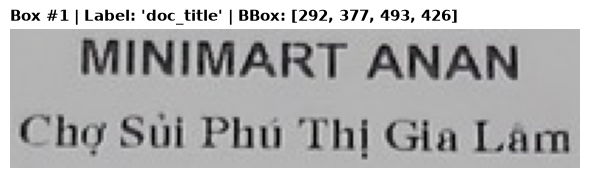

📝 Nội dung (doc_title):
MINIMART ANAN
Chợ Sửi Phú Thị Gia Lâm
------------------------------------------------------------


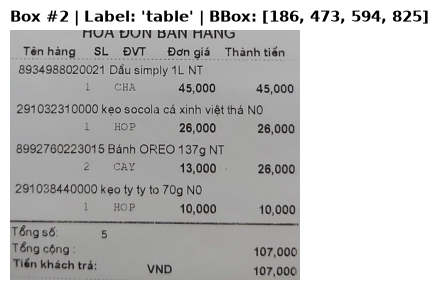

📝 Nội dung (table):
<table><tr><td colspan="4">HẠO ĐƠN BẢN HÀNG</td></tr><tr><td>Tên hàng</td><td>SL ĐVT</td><td>Đơn giá</td><td>Thành tiền</td></tr><tr><td>8934988020021</td><td>Dầu simply 1L NT</td><td></td><td></td></tr><tr><td>1</td><td>CHA</td><td>45,000</td><td>45,000</td></tr><tr><td>291032310000</td><td>kẹo socola cá xinh viết thá NO</td><td></td><td></td></tr><tr><td>1</td><td>HOP</td><td>26,000</td><td>26,000</td></tr><tr><td>8992760223015</td><td>Bánh OREO 137g NT</td><td></td><td></td></tr><tr><td>2</td><td>CAY</td><td>13,000</td><td>26,000</td></tr><tr><td>291038440000</td><td>kẹo ty ty to 70g NO</td><td></td><td></td></tr><tr><td>1</td><td>HOP</td><td>10,000</td><td>10,000</td></tr><tr><td>Tổng số:</td><td>5</td><td></td><td></td></tr><tr><td>Tổng cộng :</td><td></td><td></td><td>107,000</td></tr><tr><td>Tiến khách trả:</td><td>VND</td><td></td><td>107,000</td></tr></table>
------------------------------------------------------------


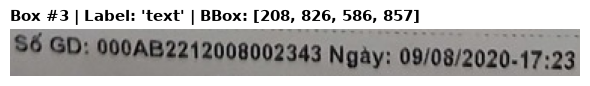

📝 Nội dung (text):
Số GD: 000AB2212008002343 Ngày: 09/08/2020-17:23
------------------------------------------------------------


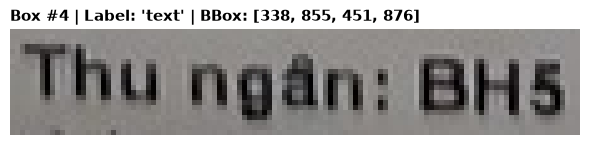

📝 Nội dung (text):
Thu ngân: BH5
------------------------------------------------------------


In [25]:
# Hiển thị từng image_patch (ảnh cắt theo bbox) kèm nhãn (label) và nội dung (content)
import json
import glob
from PIL import Image
import matplotlib.pyplot as plt

# 1. Nạp dữ liệu kết quả JSON từ output_vl
json_files_vl = glob.glob("output_vl/**/*.json", recursive=True)
if json_files_vl:
    with open(json_files_vl[0], "r", encoding="utf-8") as f:
        data_vl = json.load(f)

    # 2. Mở ảnh gốc
    img_path = image_patch
    orig_img = Image.open(img_path)

    parsing_res_list = data_vl.get("parsing_res_list", [])
    print(f"Tổng số layout blocks (boxes) tìm thấy: {len(parsing_res_list)}\n")

    # 3. Duyệt qua từng block và cắt image_patch
    for i, block in enumerate(parsing_res_list):
        label = block.get("block_label", "N/A")
        content = block.get("block_content", "").strip()
        bbox = block.get("block_bbox", None)  # [xmin, ymin, xmax, ymax]

        if bbox and len(bbox) == 4:
            xmin, ymin, xmax, ymax = [int(v) for v in bbox]
            
            # Cắt image_patch từ ảnh gốc dựa trên bbox
            image_patch = orig_img.crop((xmin, ymin, xmax, ymax))

            # Hiển thị image_patch và thông tin box
            fig, ax = plt.subplots(figsize=(6, 3))
            ax.imshow(image_patch)
            ax.axis("off")
            ax.set_title(f"Box #{i+1} | Label: '{label}' | BBox: {bbox}", fontsize=11, fontweight="bold", loc="left")
            plt.tight_layout()
            plt.show()

            print(f"📝 Nội dung ({label}):")
            print(content if content else "(Không có chữ)")
            print("-" * 60)
else:
    print("Chưa tìm thấy file output_vl JSON. Hãy chạy Cell predict trước!")

In [26]:
import gc
import paddle
# import torch  # Bỏ comment nếu dự án có dùng thêm PyTorch

# 1. Xóa biến lưu model/pipeline
if 'pipeline_vl' in globals():
    del pipeline_vl

# 2. Ép Python dọn dẹp các vùng nhớ không còn dùng
gc.collect()

# 3. Dọn sạch cache trên VRAM GPU
paddle.device.cuda.empty_cache()

# Nếu dùng thêm PyTorch thì mở dòng dưới:
# torch.cuda.empty_cache()